In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import os
import shap
from dotenv import load_dotenv
from groq import Groq
import streamlit as st
import plotly.express as px

In [3]:
df = pd.read_csv('lending_club_loan_two.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

In [5]:
df['loan_status'].nunique

<bound method IndexOpsMixin.nunique of 0          Fully Paid
1          Fully Paid
2          Fully Paid
3          Fully Paid
4         Charged Off
             ...     
396025     Fully Paid
396026     Fully Paid
396027     Fully Paid
396028     Fully Paid
396029     Fully Paid
Name: loan_status, Length: 396030, dtype: str>

In [6]:
df['loan_amnt'].max()

np.float64(40000.0)

In [7]:
df['annual_inc'].isnull() # checking if there is missing value in income column

0         False
1         False
2         False
3         False
4         False
          ...  
396025    False
396026    False
396027    False
396028    False
396029    False
Name: annual_inc, Length: 396030, dtype: bool

In [8]:
df['annual_inc'].max() # checking for extreme value 

np.float64(8706582.0)

In [9]:
top_10_values = df.nlargest(10,'annual_inc') # top 10 max value in annual_income  column
top_10_values

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
308700,8000.0,36 months,13.66,272.11,C,C3,Correctional Sgt.,10+ years,MORTGAGE,8706582.0,...,11.0,0.0,16449.0,54.1,18.0,w,INDIVIDUAL,1.0,0.0,"2410 Luna Station\nSouth Brandi, HI 93700"
318255,10000.0,36 months,6.89,308.27,A,A3,Interim Director of Case Management,3 years,MORTGAGE,7600000.0,...,18.0,0.0,2494.0,15.7,27.0,f,INDIVIDUAL,1.0,0.0,USCGC Foley\nFPO AA 00813
100370,20000.0,36 months,7.62,623.23,A,A3,Registered Nurse,5 years,RENT,7446395.0,...,10.0,0.0,24494.0,50.7,24.0,w,INDIVIDUAL,0.0,0.0,"PSC 6677, Box 0869\nAPO AP 00813"
376306,14825.0,36 months,13.11,500.30,B,B4,Us postal service,10+ years,MORTGAGE,7141778.0,...,17.0,0.0,11351.0,70.9,31.0,w,INDIVIDUAL,1.0,0.0,"1466 Tucker Highway Apt. 190\nNew Harry, GA 29597"
100946,25000.0,36 months,6.89,770.68,A,A3,Legal admin asst,6 years,MORTGAGE,7000000.0,...,22.0,0.0,25621.0,35.0,45.0,w,INDIVIDUAL,3.0,0.0,"15345 Peter Light\nNew Richardburgh, NH 70466"
117632,25000.0,60 months,8.39,511.59,B,B1,operator,10+ years,MORTGAGE,6500000.0,...,19.0,0.0,5590.0,12.7,49.0,w,INDIVIDUAL,5.0,0.0,"4912 Latoya Burgs\nGarrisonbury, NM 30723"
16169,30000.0,36 months,12.12,998.15,B,B3,BOONE AND SONS JEWELERS,10+ years,MORTGAGE,6100000.0,...,8.0,0.0,15219.0,94.5,19.0,w,INDIVIDUAL,4.0,0.0,"068 Harris Rapids\nJulietown, VA 48052"
165401,5000.0,36 months,12.73,167.84,C,C1,post office,10+ years,MORTGAGE,6000000.0,...,2.0,0.0,1434.0,37.7,10.0,f,INDIVIDUAL,NaN,0.0,"56800 Derek Corners Suite 513\nBrianborough, M..."
391587,4475.0,36 months,7.89,140.01,A,A5,consultant,10+ years,MORTGAGE,6000000.0,...,4.0,0.0,9100.0,95.8,13.0,w,INDIVIDUAL,4.0,0.0,"60438 Grant Skyway\nLake Anthonyland, MO 30723"
308857,35000.0,36 months,15.31,1218.61,C,C2,VISIUM asset management,10+ years,MORTGAGE,5000000.0,...,13.0,0.0,975800.0,0.0,36.0,w,INDIVIDUAL,8.0,0.0,"PSC 4479, Box 8462\nAPO AE 70466"


In [10]:
df['title'].nunique() # checking for unique title to take a debt

48816

In [ ]:
##Feature Engineering

In [11]:
df['loan_status'] = df['loan_status'].replace({'Fully Paid': 1,'Charged Off':0}) # replacing with simple binary value

In [12]:
df['loan_status']

0         1
1         1
2         1
3         1
4         0
         ..
396025    1
396026    1
396027    1
396028    1
396029    1
Name: loan_status, Length: 396030, dtype: object

In [13]:
df = df.drop(['emp_title','title','address','initial_list_status','grade','sub_grade','int_rate'],axis = 1) # removing the row that have no effect or can skew the predictive model

In [14]:
df['term'].unique() # checking for unique tenure for which loan has been granted

<StringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str

In [15]:
df['term'] = df['term'].replace({' 36 months': 36,' 60 months': 60}) # changing text numeric to pure numeric 

In [16]:
df['home_ownership'].unique() # homeowernship status

<StringArray>
['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'NONE', 'ANY']
Length: 6, dtype: str

In [17]:
df['verification_status'].unique()

<StringArray>
['Not Verified', 'Source Verified', 'Verified']
Length: 3, dtype: str

In [18]:
df['purpose'].unique()

<StringArray>
[          'vacation', 'debt_consolidation',        'credit_card',
   'home_improvement',     'small_business',     'major_purchase',
              'other',            'medical',            'wedding',
                'car',             'moving',              'house',
        'educational',   'renewable_energy']
Length: 14, dtype: str

In [19]:
df['purpose'].value_counts().get('renewable_energy') # no.of count for which renewable energy loan has taken

np.int64(329)

In [20]:
df['purpose'].value_counts().get('educational')

np.int64(257)

In [21]:
df['purpose'].value_counts().get('house')

np.int64(2201)

In [22]:
df['purpose'].value_counts().get('moving')

np.int64(2854)

In [23]:
df['purpose'].value_counts().get('car')

np.int64(4697)

In [24]:
df['purpose'].value_counts()

purpose
debt_consolidation    234507
credit_card            83019
home_improvement       24030
other                  21185
major_purchase          8790
small_business          5701
car                     4697
medical                 4196
moving                  2854
vacation                2452
house                   2201
wedding                 1812
renewable_energy         329
educational              257
Name: count, dtype: int64

In [25]:
df['purpose'].value_counts().get('medical')

np.int64(4196)

In [26]:
categories = ['renewable_energy','educational','house','moving','car','wedding','vacation'] 
df.loc[df['purpose'].isin(categories),'purpose'] = 'other' # categoring the low count loan for better understanding

In [27]:
df['purpose'].value_counts()

purpose
debt_consolidation    234507
credit_card            83019
other                  35787
home_improvement       24030
major_purchase          8790
small_business          5701
medical                 4196
Name: count, dtype: int64

In [28]:
df['application_type'].unique()

<StringArray>
['INDIVIDUAL', 'JOINT', 'DIRECT_PAY']
Length: 3, dtype: str

In [29]:
df['application_type'].value_counts()

application_type
INDIVIDUAL    395319
JOINT            425
DIRECT_PAY       286
Name: count, dtype: int64

In [30]:
app_types = ['JOINT', 'DIRECT_PAY']  # grouping joint and direct pay as count are very low

df.loc[df['application_type'].isin(app_types), 'application_type'] = 'other'

In [31]:
df['application_type'].value_counts()

application_type
INDIVIDUAL    395319
other            711
Name: count, dtype: int64

In [32]:
df.head()

,loan_amnt,term,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies
0,10000.0,36,329.48,10+ years,RENT,117000.0,Not Verified,Jan-2015,1,other,26.24,Jun-1990,16.0,0.0,36369.0,41.8,25.0,INDIVIDUAL,0.0,0.0
1,8000.0,36,265.68,4 years,MORTGAGE,65000.0,Not Verified,Jan-2015,1,debt_consolidation,22.05,Jul-2004,17.0,0.0,20131.0,53.3,27.0,INDIVIDUAL,3.0,0.0
2,15600.0,36,506.97,< 1 year,RENT,43057.0,Source Verified,Jan-2015,1,credit_card,12.79,Aug-2007,13.0,0.0,11987.0,92.2,26.0,INDIVIDUAL,0.0,0.0
3,7200.0,36,220.65,6 years,RENT,54000.0,Not Verified,Nov-2014,1,credit_card,2.60,Sep-2006,6.0,0.0,5472.0,21.5,13.0,INDIVIDUAL,0.0,0.0
4,24375.0,60,609.33,9 years,MORTGAGE,55000.0,Verified,Apr-2013,0,credit_card,33.95,Mar-1999,13.0,0.0,24584.0,69.8,43.0,INDIVIDUAL,1.0,0.0


In [33]:
df.isnull().sum()

loan_amnt                   0
term                        0
installment                 0
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
dtype: int64

In [34]:
df['emp_length'].unique()

<StringArray>
['10+ years',   '4 years',  '< 1 year',   '6 years',   '9 years',   '2 years',
   '3 years',   '8 years',   '7 years',   '5 years',    '1 year',         nan]
Length: 12, dtype: str

In [35]:
length_map = {
    '< 1 year':0,
    '1 year':1,
    '2 years':2,
    '3 years':3,
    '4 years':4,
    '5 years':5,
    '6 years':6,
    '7 years':7,
    '8 years':8,
    '9 years':9,
    '10+ years':10
}
df['emp_length'] = df['emp_length'].map(length_map)

In [36]:
df['emp_length_miss_value'] = df['emp_length'].isnull().astype(int)

In [37]:
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median()) # fill the null value with median of that column

In [38]:
df['emp_length'].isnull().sum()

np.int64(0)

In [39]:
df.head()

,loan_amnt,term,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,...,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,emp_length_miss_value
0,10000.0,36,329.48,10.0,RENT,117000.0,Not Verified,Jan-2015,1,other,...,Jun-1990,16.0,0.0,36369.0,41.8,25.0,INDIVIDUAL,0.0,0.0,0
1,8000.0,36,265.68,4.0,MORTGAGE,65000.0,Not Verified,Jan-2015,1,debt_consolidation,...,Jul-2004,17.0,0.0,20131.0,53.3,27.0,INDIVIDUAL,3.0,0.0,0
2,15600.0,36,506.97,0.0,RENT,43057.0,Source Verified,Jan-2015,1,credit_card,...,Aug-2007,13.0,0.0,11987.0,92.2,26.0,INDIVIDUAL,0.0,0.0,0
3,7200.0,36,220.65,6.0,RENT,54000.0,Not Verified,Nov-2014,1,credit_card,...,Sep-2006,6.0,0.0,5472.0,21.5,13.0,INDIVIDUAL,0.0,0.0,0
4,24375.0,60,609.33,9.0,MORTGAGE,55000.0,Verified,Apr-2013,0,credit_card,...,Mar-1999,13.0,0.0,24584.0,69.8,43.0,INDIVIDUAL,1.0,0.0,0


In [40]:
ownership = df['home_ownership'].value_counts()[df['home_ownership'].value_counts()< 200].index.tolist()
df.loc[df['home_ownership'].isin(ownership),'home_ownership'] = 'OTHER' # categoring the low count in one other group

In [41]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198348
RENT        159790
OWN          37746
OTHER          146
Name: count, dtype: int64

In [42]:
df['verification_status'].value_counts()

verification_status
Verified           139563
Source Verified    131385
Not Verified       125082
Name: count, dtype: int64

In [43]:
df= pd.get_dummies(df,columns = ['verification_status'],drop_first = True)

In [44]:
df['revol_util'].value_counts()

revol_util
0.00      2213
53.00      752
60.00      739
61.00      734
55.00      730
          ... 
119.20       1
62.31        1
56.26        1
111.40       1
128.10       1
Name: count, Length: 1226, dtype: int64

In [45]:
df[df['revol_util'].isnull()]['revol_bal'].describe()

count       276.000000
mean       9608.474638
std       30970.881105
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      232186.000000
Name: revol_bal, dtype: float64

In [46]:
df.loc[(df['revol_util'].isnull()) & (df['revol_bal'] == 0), 'revol_util'] = 0 
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

In [47]:
df['revol_util'].isnull().sum()

np.int64(0)

In [48]:
df['mort_acc'].isnull().sum()

np.int64(37795)

In [49]:
avg = df.groupby('total_acc')['mort_acc'].mean() # filling missing value of mortage account by total account withspecific group instead filling with just straight median to avoid discrepancies.

def fill_mort_acc(row):
    if pd.isnull(row['mort_acc']):
        return avg.loc[row['total_acc']]
    return row['mort_acc']
df['mort_acc'] = df.apply(fill_mort_acc, axis =1)
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())

In [50]:
df['mort_acc'].isnull().sum()

np.int64(0)

In [51]:
df['pub_rec_bankruptcies'].value_counts()

pub_rec_bankruptcies
0.0    350380
1.0     42790
2.0      1847
3.0       351
4.0        82
5.0        32
6.0         7
7.0         4
8.0         2
Name: count, dtype: int64

In [52]:
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)

In [53]:
df['pub_rec_bankruptcies'].isnull().sum()

np.int64(0)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            396030 non-null  float64
 1   term                                 396030 non-null  object 
 2   installment                          396030 non-null  float64
 3   emp_length                           396030 non-null  float64
 4   home_ownership                       396030 non-null  str    
 5   annual_inc                           396030 non-null  float64
 6   issue_d                              396030 non-null  str    
 7   loan_status                          396030 non-null  object 
 8   purpose                              396030 non-null  str    
 9   dti                                  396030 non-null  float64
 10  earliest_cr_line                     396030 non-null  str    
 11  open_acc                

In [55]:
df = pd.get_dummies(df, columns=['home_ownership', 'purpose', 'application_type'], drop_first=True) 

In [56]:
df.dtypes

loan_amnt                              float64
term                                    object
installment                            float64
emp_length                             float64
annual_inc                             float64
issue_d                                    str
loan_status                             object
dti                                    float64
earliest_cr_line                           str
open_acc                               float64
pub_rec                                float64
revol_bal                              float64
revol_util                             float64
total_acc                              float64
mort_acc                               float64
pub_rec_bankruptcies                   float64
emp_length_miss_value                    int64
verification_status_Source Verified       bool
verification_status_Verified              bool
home_ownership_OTHER                      bool
home_ownership_OWN                        bool
home_ownershi

In [57]:
df['term'] = df['term'].astype(str).str.strip().str.replace(' months', '', regex=False).astype(int)

In [58]:
df['loan_status'] = df['loan_status'].astype(int)

In [59]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
df = df.drop(columns=['earliest_cr_line', 'issue_d'])

C:\Users\itsra\AppData\Local\Temp\ipykernel_8584\1122342789.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
C:\Users\itsra\AppData\Local\Temp\ipykernel_8584\1122342789.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])


In [60]:
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [61]:
df['loan_status']

0         1
1         1
2         1
3         1
4         0
         ..
396025    1
396026    1
396027    1
396028    1
396029    1
Name: loan_status, Length: 396030, dtype: int64

In [62]:
df['loan_status'].value_counts(normalize=True)

loan_status
1    0.803871
0    0.196129
Name: proportion, dtype: float64

In [63]:
df['loan_status'] = df['loan_status'].replace({0: 1,1:0}) 

In [64]:
df['loan_status'].value_counts()

loan_status
0    318357
1     77673
Name: count, dtype: int64

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 28 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            396030 non-null  float64
 1   term                                 396030 non-null  int64  
 2   installment                          396030 non-null  float64
 3   emp_length                           396030 non-null  float64
 4   annual_inc                           396030 non-null  float64
 5   loan_status                          396030 non-null  int64  
 6   dti                                  396030 non-null  float64
 7   open_acc                             396030 non-null  float64
 8   pub_rec                              396030 non-null  float64
 9   revol_bal                            396030 non-null  float64
 10  revol_util                           396030 non-null  float64
 11  total_acc               

In [66]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.803871
1    0.196129
Name: proportion, dtype: float64

In [67]:
df.to_csv('Loan_default_Prediction.csv',index = False)

In [68]:
os.path.exists('Loan_default_Prediction.csv')

True

In [69]:
# predicting model

X = df.drop(columns = ['loan_status'])
Y = df['loan_status']

In [70]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size =0.2, random_state = 42, stratify = Y)


In [71]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [72]:
reg = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
reg.fit(X_train_scale,Y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [73]:
y_pred = reg.predict(X_test_scale)
print(classification_report(Y_test,y_pred))
print("AUC:", roc_auc_score(Y_test, reg.predict_proba(X_test_scale)[:, 1]))

              precision    recall  f1-score   support

           0       0.87      0.67      0.76     63671
           1       0.31      0.60      0.41     15535

    accuracy                           0.66     79206
   macro avg       0.59      0.64      0.58     79206
weighted avg       0.76      0.66      0.69     79206

AUC: 0.6903226165190175


In [74]:
# prediction using XGBoost
xgb = XGBClassifier(Scale_pos_weight = (Y_train.value_counts()[0]/Y_train.value_counts()[1]), random_state = 42)
xgb.fit(X_train,Y_train)

y_pre_xgb = xgb.predict(X_test)
print(classification_report(Y_test,y_pre_xgb))
print("AUC:", roc_auc_score(Y_test, xgb.predict_proba(X_test)[:, 1]))


C:\Users\itsra\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:08:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "Scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.82      0.98      0.89     63671
           1       0.55      0.09      0.16     15535

    accuracy                           0.81     79206
   macro avg       0.68      0.54      0.52     79206
weighted avg       0.76      0.81      0.75     79206

AUC: 0.7085457974927305


In [75]:
y_probs = xgb.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_probs >= 0.3).astype(int)


print(classification_report(Y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85     63671
           1       0.39      0.38      0.39     15535

    accuracy                           0.76     79206
   macro avg       0.62      0.62      0.62     79206
weighted avg       0.76      0.76      0.76     79206



In [76]:
# SHAP explainabiltiy
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

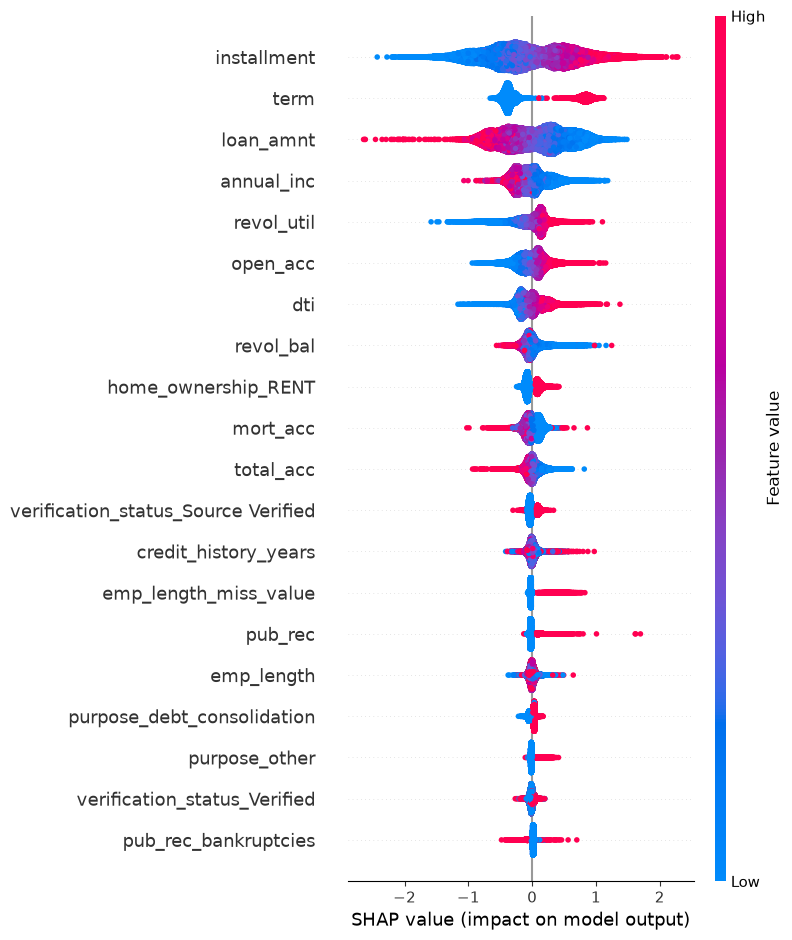

In [77]:
shap.summary_plot(shap_values, X_test)

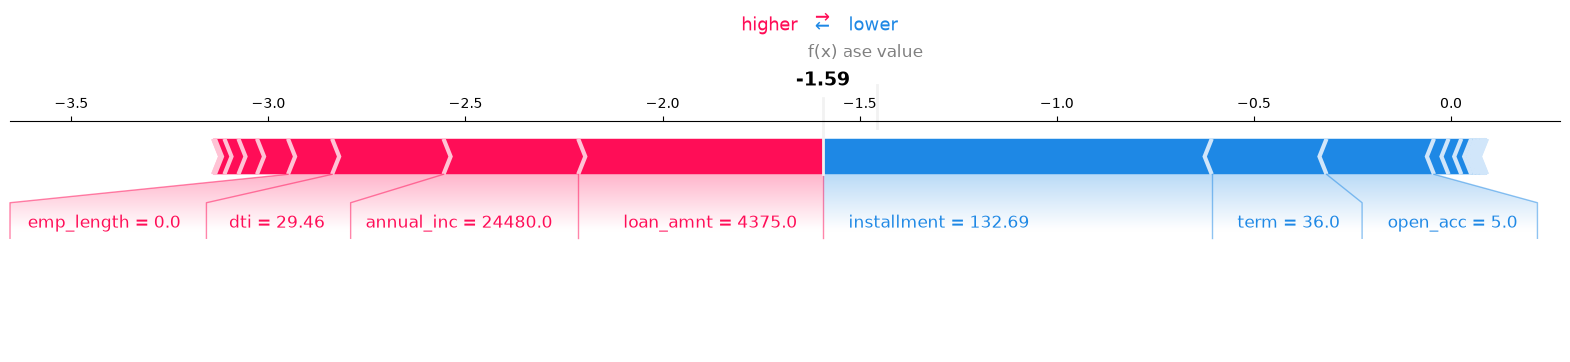

In [78]:
i = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i],
    matplotlib = True
)

In [79]:
def get_top_factors(index, top_n=3):
    contributions = pd.Series(shap_values[index], index=X_test.columns)
    top_factors = contributions.abs().sort_values(ascending=False).head(top_n)
    result = []
    for feature in top_factors.index:
        result.append({
            'feature': feature,
            'value': X_test.iloc[index][feature],
            'contribution': contributions[feature]
        })
    return result

get_top_factors(0)

[{'feature': 'installment',
  'value': np.float64(132.69),
  'contribution': np.float32(-0.98648083)},
 {'feature': 'loan_amnt',
  'value': np.float64(4375.0),
  'contribution': np.float32(0.6206711)},
 {'feature': 'annual_inc',
  'value': np.float64(24480.0),
  'contribution': np.float32(0.34168878)}]

In [80]:
y_probs = xgb.predict_proba(X_test)[:, 1]
high_risk_indices = X_test[y_probs >= 0.35].index

for idx in high_risk_indices[:5]:
    pos = X_test.index.get_loc(idx)
    print(f"Applicant {idx}: {get_top_factors(pos)}")

Applicant 369517: [{'feature': 'loan_amnt', 'value': np.float64(9550.0), 'contribution': np.float32(0.5207849)}, {'feature': 'annual_inc', 'value': np.float64(30000.0), 'contribution': np.float32(0.5145064)}, {'feature': 'term', 'value': np.float64(36.0), 'contribution': np.float32(-0.2574502)}]
Applicant 357741: [{'feature': 'term', 'value': np.float64(60.0), 'contribution': np.float32(0.8958857)}, {'feature': 'open_acc', 'value': np.float64(4.0), 'contribution': np.float32(-0.57007635)}, {'feature': 'revol_bal', 'value': np.float64(2970.0), 'contribution': np.float32(0.31415057)}]
Applicant 340422: [{'feature': 'term', 'value': np.float64(60.0), 'contribution': np.float32(0.85557204)}, {'feature': 'installment', 'value': np.float64(779.72), 'contribution': np.float32(0.8060988)}, {'feature': 'loan_amnt', 'value': np.float64(28000.0), 'contribution': np.float32(-0.60612214)}]
Applicant 18989: [{'feature': 'annual_inc', 'value': np.float64(25000.0), 'contribution': np.float32(0.5503092

In [81]:
def build_prompt(applicant_id, factors):
    factor_lines = []
    for f in factors:
        direction = "increased" if f['contribution'] > 0 else "decreased"
        factor_lines.append(f"- {f['feature']} = {f['value']} ({direction} risk)")
    
    factor_text = "\n".join(factor_lines)
    
    prompt = f"""You are explaining a loan risk assessment to a loan officer.
Write a natural, varied 2-sentence explanation — avoid repeating the exact same sentence structure each time.Do not invent any information not given below.

Factors:
{factor_text}

Explanation:"""
    return prompt

print(build_prompt(369517, get_top_factors(X_test.index.get_loc(369517))))

You are explaining a loan risk assessment to a loan officer.
Write a natural, varied 2-sentence explanation — avoid repeating the exact same sentence structure each time.Do not invent any information not given below.

Factors:
- loan_amnt = 9550.0 (increased risk)
- annual_inc = 30000.0 (increased risk)
- term = 36.0 (decreased risk)

Explanation:


In [97]:
load_dotenv()  
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def generate_explanation(applicant_id, factors):
    prompt = build_prompt(applicant_id, factors)
    
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}]
    )
    
    return response.choices[0].message.content

In [98]:
test_factors = get_top_factors(X_test.index.get_loc(sampled_indices[0]))
print(generate_explanation(sampled_indices[0], test_factors))

The borrower’s debt‑to‑income ratio of 44.22% flags elevated risk, showing that a sizable share of their earnings is already tied up in debt payments. Moreover, the missing employment‑length indicator (value 1.0) combined with a monthly installment of $536.81 further heightens the risk assessment.


In [92]:
print(f"Total flagged applicants: {len(high_risk_indices)}")

Total flagged applicants: 10278


In [99]:
import json   # Generating 100 explanation
import time

all_explanations = {}

for idx in sampled_indices:
    pos = X_test.index.get_loc(idx)
    factors = get_top_factors(pos)
    
    try:
        explanation = generate_explanation(idx, factors)
        all_explanations[str(idx)] = {
            "explanation": explanation,
            "factors": [
                {
                    "feature": f["feature"],
                    "value": float(f["value"]),
                    "contribution": float(f["contribution"])
                }
                for f in factors
            ]
        }
    except Exception as e:
        print(f"Failed for applicant {idx}: {e}")
        continue
    
    time.sleep(2)

print(f"Generated {len(all_explanations)} explanations")

Generated 100 explanations


In [100]:
with open('explanations.json', 'w') as f:  # saving all 100 explanation in json file
    json.dump(all_explanations, f, indent=2)

print("Saved to explanations.json")

Saved to explanations.json


In [101]:
with open('explanations.json', 'r') as f:
    data = json.load(f)

print(f"Total saved: {len(data)}")
print(json.dumps(list(data.items())[0], indent=2))  

Total saved: 100
[
  "30090",
  {
    "explanation": "The applicant\u2019s debt\u2011to\u2011income ratio of\u202f44.22% signals heightened risk, indicating a large share of income is already tied up in existing obligations. Additionally, the missing employment\u2011length value (recorded as\u202f1.0) together with a $536.81 monthly installment further amplifies the risk profile.",
    "factors": [
      {
        "feature": "dti",
        "value": 44.22,
        "contribution": 1.3755013942718506
      },
      {
        "feature": "emp_length_miss_value",
        "value": 1.0,
        "contribution": 0.731256902217865
      },
      {
        "feature": "installment",
        "value": 536.81,
        "contribution": 0.42217111587524414
      }
    ]
  }
]


In [120]:
# 1. Test set with predictions and actual outcomes
export_df = X_test.copy()
export_df['actual_status'] = Y_test.values
export_df['predicted_probability'] = y_probs
export_df['predicted_risk'] = (y_probs >= 0.35).astype(int)
export_df.to_csv('model_predictions.csv', index=False)

# 2. Model comparison metrics (for a summary table/card in Power BI)
metrics_df = pd.DataFrame([
    {'model': 'Logistic Regression', 'recall': 0.60, 'precision': 0.31, 'auc': 0.69},
    {'model': 'XGBoost (0.5 threshold)', 'recall': 0.09, 'precision': 0.55, 'auc': 0.71},
    {'model': 'XGBoost (tuned)', 'recall': 0.38, 'precision': 0.39, 'auc': 0.71},
])
metrics_df.to_csv('model_metrics.csv', index=False)

# 3. SHAP feature importance (global)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
importance_df.to_csv('shap_importance.csv', index=False)

# 4. Applicant-level explanations (JSON into a table)
rows = []
for applicant_id, entry in all_explanations.items():
    for f in entry['factors']:
        rows.append({
            'applicant_id': applicant_id,
            'explanation': entry['explanation'],
            'feature': f['feature'],
            'value': f['value'],
            'contribution': f['contribution'],
        })
explanations_flat_df = pd.DataFrame(rows)
explanations_flat_df.to_csv('applicant_explanations.csv', index=False)